# Análisis de algoritmo paralelo kNN

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df  = pd.read_csv('results/knn_digits_results.csv')
df

,Processes,Subset_%,N_train,N_test,T_comp (s),T_comm (s),T_total (s),GFLOP/s,Accuracy
0,1,25,359,90,0.113720,0.000000,0.113720,0.054551,0.977778
1,1,50,718,180,0.431752,0.000000,0.431752,0.057473,0.983333
2,1,75,1077,270,0.926700,0.000000,0.926700,0.060248,0.996296
3,1,100,1437,360,1.630628,0.000000,1.630628,0.060912,0.983333
4,2,25,359,90,0.054231,0.000409,0.054646,0.057196,0.977778
5,2,50,718,180,0.222919,0.000363,0.223292,0.055657,0.983333
6,2,75,1077,270,0.508559,0.003329,0.511901,0.054892,0.996296
7,2,100,1437,360,0.918079,0.000717,0.918805,0.054094,0.983333
8,4,25,359,90,0.031238,0.000557,0.031802,0.050750,0.977778
9,4,50,718,180,0.128484,0.003277,0.131775,0.048282,0.983333


In [6]:
t1_map = df[df['Processes'] == 1].set_index('Subset_%')['T_total (s)'].to_dict()
df['T_s_base'] = df['Subset_%'].map(t1_map)
df['Speedup'] = df['T_s_base'] / df['T_total (s)']
df['Efficiency'] = df['Speedup'] / df['Processes']

df.drop(columns=['T_s_base'], inplace=True)

df_100 = df[df['Subset_%'] == 100].copy()
df_100.reset_index(drop=True, inplace=True)

df_100

,Processes,Subset_%,N_train,N_test,T_comp (s),T_comm (s),T_total (s),GFLOP/s,Accuracy,Speedup,Efficiency
0,1,100,1437,360,1.630628,0.000000,1.630628,0.060912,0.983333,1.000000,1.000000
1,2,100,1437,360,0.918079,0.000717,0.918805,0.054094,0.983333,1.774726,0.887363
2,4,100,1437,360,0.515381,0.009079,0.524474,0.048181,0.983333,3.109076,0.777269
3,8,100,1437,360,0.423315,0.020865,0.444194,0.029330,0.983333,3.670983,0.458873


### Tiempos de ejecución $T_{comp}$, $T_{comm}$, $T_{total}$

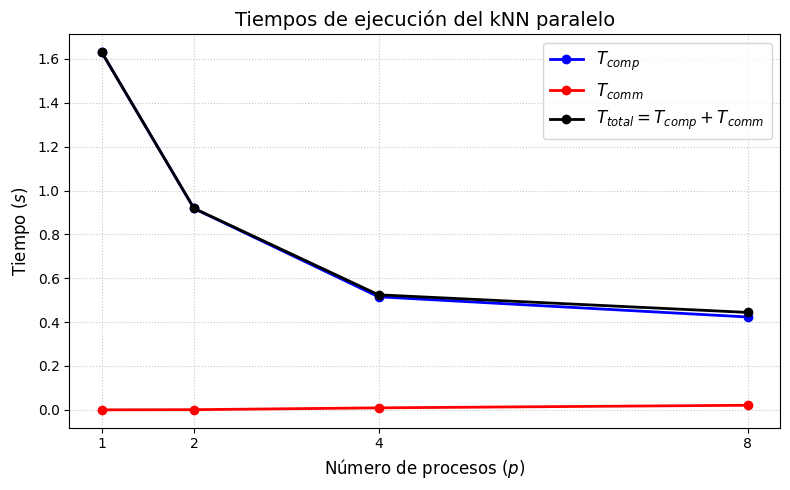

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(df_100['Processes'], df_100['T_comp (s)'], marker='o', linestyle='-', color='b', label='$T_{comp}$', linewidth=2)
plt.plot(df_100['Processes'], df_100['T_comm (s)'], marker='o', linestyle='-', color='r', label='$T_{comm}$', linewidth=2)
plt.plot(df_100['Processes'], df_100['T_total (s)'], marker='o', linestyle='-', color='black', label='$T_{total} = T_{comp} + T_{comm}$', linewidth=2)

plt.title('Tiempos de ejecución del kNN paralelo', fontsize=14)
plt.xlabel('Número de procesos ($p$)', fontsize=12)
plt.ylabel('Tiempo ($s$)', fontsize=12)
plt.grid(True, linestyle=":", alpha=0.7)
plt.xticks(df_100['Processes'])
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### Cómputo $T_{comp}$ vs Comunicación $T_{comm}$

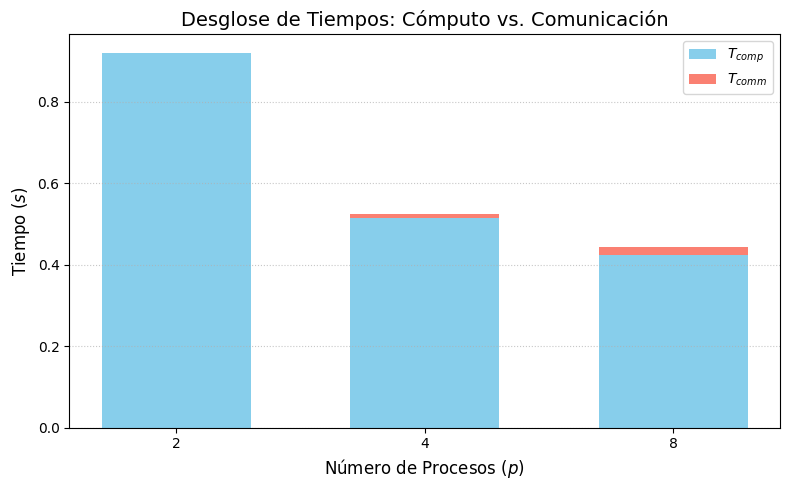

In [29]:
plt.figure(figsize=(8, 5))

df_mpi = df_100[df_100['Processes'] > 1]
x_labels_bar = df_mpi['Processes'].astype(str)

plt.bar(x_labels_bar, df_mpi['T_comp (s)'], color='skyblue', label='$T_{comp}$', width=0.6)
plt.bar(x_labels_bar, df_mpi['T_comm (s)'], bottom=df_mpi['T_comp (s)'], color='salmon', label='$T_{comm}$', width=0.6)

plt.title('Desglose de Tiempos: Cómputo vs. Comunicación', fontsize=14)
plt.xlabel('Número de Procesos ($p$)', fontsize=12)
plt.ylabel('Tiempo ($s$)', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

### Accuracy del kNN paralelo

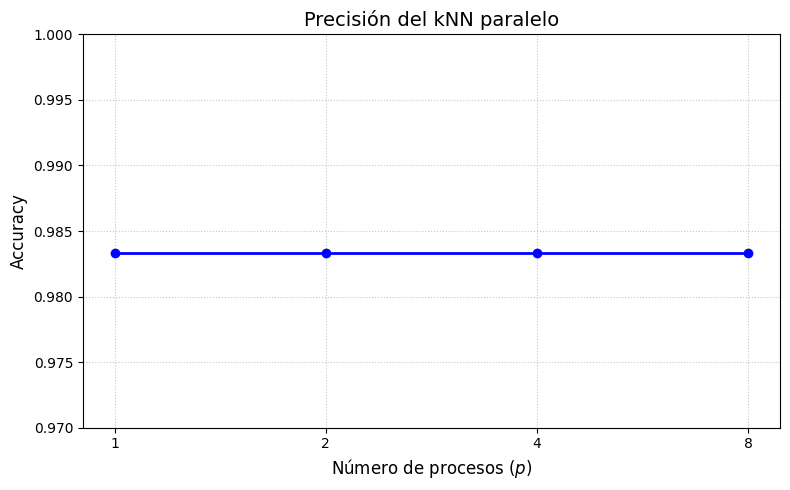

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(x_labels, df_100['Accuracy'], marker='o', linestyle='-', color='b', linewidth=2)

plt.title('Precisión del kNN paralelo', fontsize=14)
plt.xlabel('Número de procesos ($p$)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

plt.ylim(0.97, 1.0)

plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()

### Cálculo del Speedup $S = T_s / T_p$

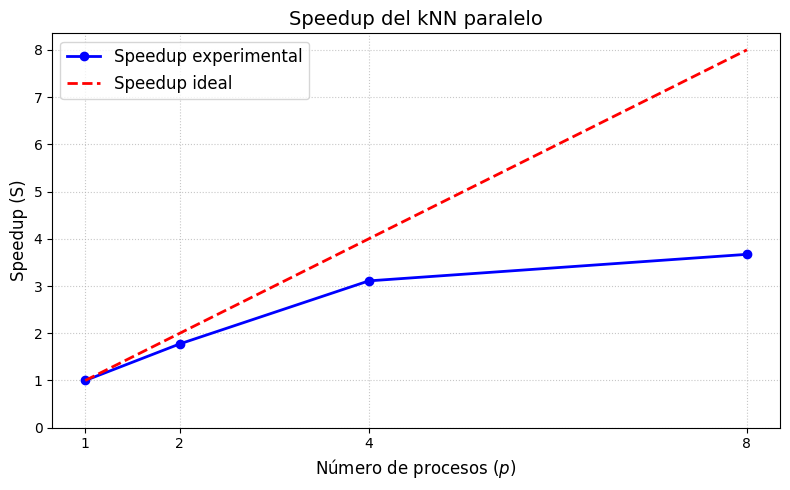

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(df_100['Processes'], df_100['Speedup'], marker='o', linestyle='-', color='b', label='Speedup experimental', linewidth=2)
plt.plot(df_100['Processes'], df_100['Processes'], marker='', linestyle='--', color='r', label='Speedup ideal', linewidth=2)

plt.title('Speedup del kNN paralelo', fontsize=14)
plt.xlabel('Número de procesos ($p$)', fontsize=12)
plt.ylabel('Speedup (S)', fontsize=12)
plt.xticks(df_100['Processes'])
plt.ylim(bottom=0)
plt.grid(True, linestyle=":", alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### FLOP/s de ejecución del kNN

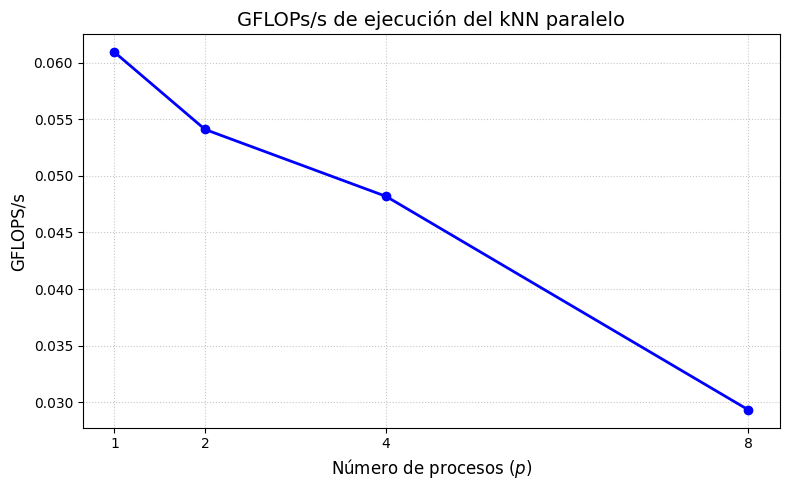

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(df_100['Processes'], df_100['GFLOP/s'], marker='o', linestyle='-', color='b', linewidth=2)

plt.title('GFLOPs/s de ejecución del kNN paralelo', fontsize=14)
plt.xlabel('Número de procesos ($p$)', fontsize=12)
plt.ylabel('GFLOPS/s', fontsize=12)
plt.xticks(df_100['Processes'])
plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()

### Eficiencia del kNN paralelo

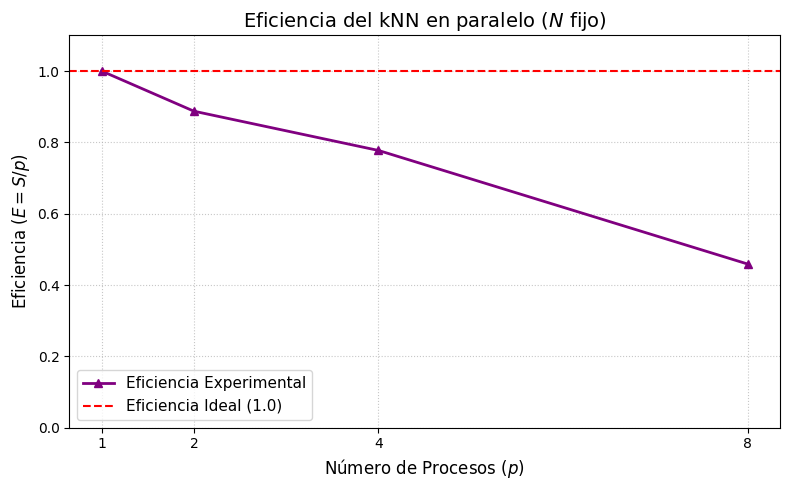

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(df_100['Processes'], df_100['Efficiency'], marker='^', linestyle='-', color='purple', label='Eficiencia Experimental', linewidth=2)
plt.axhline(y=1.0, color='r', linestyle='--', label='Eficiencia Ideal (1.0)')

plt.title('Eficiencia del kNN en paralelo ($N$ fijo)', fontsize=14)
plt.xlabel('Número de Procesos ($p$)', fontsize=12)
plt.ylabel('Eficiencia ($E = S / p$)', fontsize=12)
plt.xticks(df_100['Processes'])
plt.ylim(0, 1.1)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

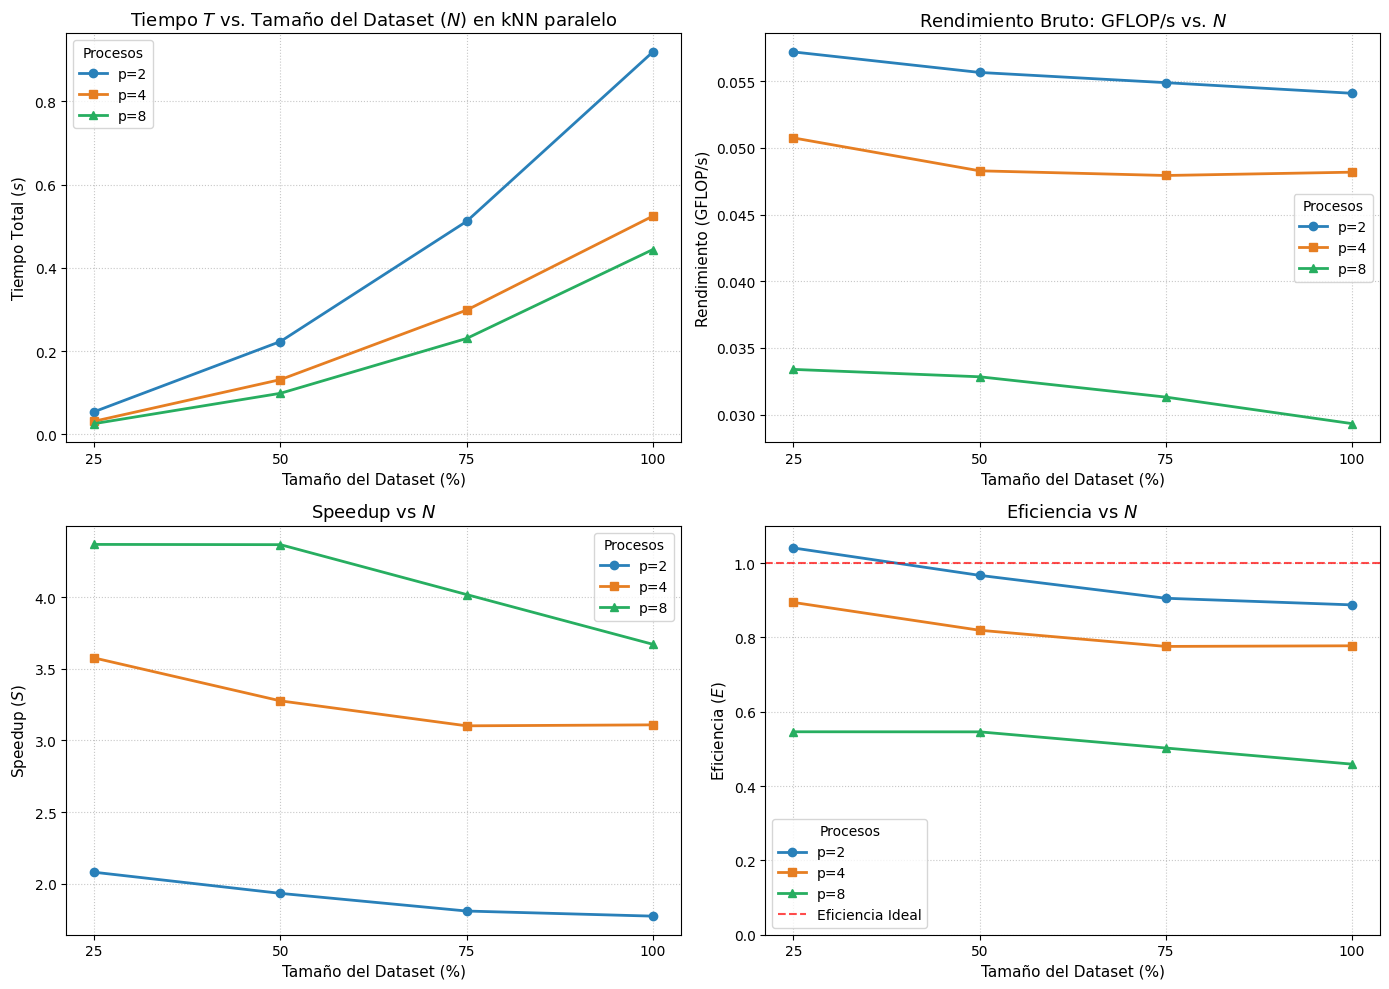

In [33]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

df_mpi_np = df[df['Processes'] > 1]

estilos = {
    2: {'marker': 'o', 'color': '#2980b9'},
    4: {'marker': 's', 'color': '#e67e22'},
    8: {'marker': '^', 'color': '#27ae60'}
}

for p in sorted(df_mpi_np['Processes'].unique()):
    df_p = df_mpi_np[df_mpi_np['Processes'] == p]
    m = estilos.get(p, {'marker': 'x'})['marker']
    c = estilos.get(p, {'color': 'black'})['color']
    ax1.plot(df_p['Subset_%'], df_p['T_total (s)'], marker=m, color=c, linewidth=2, label=f'p={p}')
    
ax1.set_title('Tiempo $T$ vs. Tamaño del Dataset ($N$) en kNN paralelo', fontsize=13)
ax1.set_xlabel('Tamaño del Dataset (%)', fontsize=11)
ax1.set_ylabel('Tiempo Total ($s$)', fontsize=11)
ax1.set_xticks([25, 50, 75, 100])
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend(title='Procesos')

for p in sorted(df_mpi_np['Processes'].unique()):
    df_p = df_mpi_np[df_mpi_np['Processes'] == p]
    m = estilos.get(p, {'marker': 'x'})['marker']
    c = estilos.get(p, {'color': 'black'})['color']
    ax2.plot(df_p['Subset_%'], df_p['GFLOP/s'], marker=m, color=c, linewidth=2, label=f'p={p}')
    
ax2.set_title('Rendimiento Bruto: GFLOP/s vs. $N$', fontsize=13)
ax2.set_xlabel('Tamaño del Dataset (%)', fontsize=11)
ax2.set_ylabel('Rendimiento (GFLOP/s)', fontsize=11)
ax2.set_xticks([25, 50, 75, 100])
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend(title='Procesos')

for p in sorted(df_mpi_np['Processes'].unique()):
    df_p = df_mpi_np[df_mpi_np['Processes'] == p]
    m = estilos.get(p, {'marker': 'x'})['marker']
    c = estilos.get(p, {'color': 'black'})['color']
    ax3.plot(df_p['Subset_%'], df_p['Speedup'], marker=m, color=c, linewidth=2, label=f'p={p}')
    
ax3.set_title('Speedup vs $N$', fontsize=13)
ax3.set_xlabel('Tamaño del Dataset (%)', fontsize=11)
ax3.set_ylabel('Speedup ($S$)', fontsize=11)
ax3.set_xticks([25, 50, 75, 100])
ax3.grid(True, linestyle=':', alpha=0.7)
ax3.legend(title='Procesos')

for p in sorted(df_mpi_np['Processes'].unique()):
    df_p = df_mpi_np[df_mpi_np['Processes'] == p]
    m = estilos.get(p, {'marker': 'x'})['marker']
    c = estilos.get(p, {'color': 'black'})['color']
    ax4.plot(df_p['Subset_%'], df_p['Efficiency'], marker=m, color=c, linewidth=2, label=f'p={p}')

ax4.axhline(y=1.0, color='r', linestyle='--', label='Eficiencia Ideal', alpha=0.7)
ax4.set_title('Eficiencia vs $N$', fontsize=13)
ax4.set_xlabel('Tamaño del Dataset (%)', fontsize=11)
ax4.set_ylabel('Eficiencia ($E$)', fontsize=11)
ax4.set_xticks([25, 50, 75, 100])
ax4.set_ylim(0, 1.1)
ax4.grid(True, linestyle=':', alpha=0.7)
ax4.legend(title='Procesos')

plt.tight_layout()
plt.show()